In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow import keras
import keras.ops as ops
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, classification_report, confusion_matrix


print('TensorFlow:', tf.__version__)
DataSetLocation = "C:/Users/moh/Desktop/projects/ANN from scatch/Part3/DS"

TensorFlow: 2.21.0


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(f"{DataSetLocation}/arkansas.csv")

print("=== Unique values in 'cropland' column ===")
print(df['cropland'].value_counts().sort_index())
print("\nTotal rows:", len(df))


AR_LABEL_MAP = {1:0, 2:1, 3:2, 5:3, 99:4}
df['label'] = df['cropland'].map(AR_LABEL_MAP)
print("\n=== Mapped label distribution ===")
print(df['label'].value_counts(dropna=False).sort_index())
print("\nRows with NaN label (unmapped):", df['label'].isna().sum())

=== Unique values in 'cropland' column ===
cropland
1     1522
2      762
3     2423
5     4677
99     616
Name: count, dtype: int64

Total rows: 10000

=== Mapped label distribution ===
label
0    1522
1     762
2    2423
3    4677
4     616
Name: count, dtype: int64

Rows with NaN label (unmapped): 0


In [ ]:
T          = 36     
C          = 10     
D_MODEL    = 64     
N_HEADS    = 5      
N_STAGES   = 3      
KERNEL     = 3      
DROPOUT    = 0.1
BATCH_SIZE = 32
EPOCHS     = 200
LR         = 1e-3


N_CLASSES_AR = 5
N_CLASSES_CA = 6

In [4]:

BANDS = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']

AR_LABEL_MAP = {1:0, 2:1, 3:2, 5:3, 99:4}  
CA_LABEL_MAP = {3:0, 36:1, 69:2, 75:3, 204:4, 99:5}

AR_CLASS_NAMES = ['Corn', 'Cotton', 'Rice', 'Soybeans', 'Others']
CA_CLASS_NAMES = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

def load_dataset(csv_path, label_map, n_classes, T=36, train_per_class=240, val_per_class=60, random_seed=42):
    df = pd.read_csv(csv_path)
    df['label'] = df['cropland'].map(label_map)
    df = df.dropna(subset=['label'])
    df['label'] = df['label'].astype(int)
    spectral_cols = [f'{t}_{b}' for t in range(T) for b in BANDS]
    X = df[spectral_cols].values.astype(np.float32).reshape(-1, T, len(BANDS))
    missing_cols = [f'{t}_missing_{t}' for t in range(T)] 
    M = df[missing_cols].values.astype(np.float32)
    y = df['label'].values
    rng = np.random.default_rng(random_seed)
    tr_idx, vl_idx, te_idx = [], [], []
    for cls in range(n_classes):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)
        n = len(idx)
        tr_limit = min(train_per_class, n)
        vl_limit = min(val_per_class, n - tr_limit)
        tr_idx.extend(idx[:tr_limit])
        vl_idx.extend(idx[tr_limit:tr_limit + vl_limit])
        te_idx.extend(idx[tr_limit + vl_limit:])
    def get_split(i):
        return X[i], M[i], y[i]
    train = get_split(tr_idx)
    val   = get_split(vl_idx)
    test  = get_split(te_idx)

    print(f"Loaded {csv_path}: Train={len(tr_idx)}, Val={len(vl_idx)}, Test={len(te_idx)}")
    return train, val, test

In [5]:
def alpe_block(x, mask, d_model, name="alpe"):
    T = ops.shape(x)[1]
    positions = ops.cast(ops.arange(T), "float32")[:, None]
    dims = ops.cast(ops.arange(d_model), "float32")[None, :]
    angles = positions / ops.power(10000.0, (2.0 * (dims // 2)) / ops.cast(d_model, "float32"))
    sin_pe = ops.sin(angles[:, 0::2])
    cos_pe = ops.cos(angles[:, 1::2])
    pe = ops.stack([sin_pe, cos_pe], axis=-1)
    pe = ops.reshape(pe, [1, T, d_model])
    missing_weight = 1.0 - ops.expand_dims(ops.cast(mask, "float32"), -1)
    pe = pe * missing_weight
    pe = keras.layers.Conv1D(d_model, 3, padding='same', use_bias=False, name=f"{name}_conv")(pe)
    pe = keras.layers.BatchNormalization(name=f"{name}_bn")(pe)
    gap = ops.mean(pe, axis=1, keepdims=True)
    weights = keras.layers.Conv1D(d_model, 1, padding='same', activation='sigmoid', name=f"{name}_eca")(gap)
    pe = pe * weights

    return pe

In [6]:
def cnn_sub_module(x, d_model, kernel_size=3, name="cnn"):
    residual = layers.Conv1D(d_model, 1, padding='same', use_bias=False)(x)
    out = layers.Conv1D(d_model, kernel_size, padding='same', use_bias=False)(x)
    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out)
    out = layers.Conv1D(d_model, kernel_size, padding='same', use_bias=False)(out)
    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out + residual)
    return out

def transformer_sub_module(x, d_model, n_heads, dropout=0.1, name="trans"):
    attn_out = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model//n_heads)(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)
    ffn_out = layers.Dense(d_model * 4, activation='relu')(x)
    ffn_out = layers.Dense(d_model)(ffn_out)
    ffn_out = layers.Dropout(dropout)(ffn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_out)
    return x

In [7]:
def sinusoidal_pe(x, d_model):
    T_sym  = ops.shape(x)[1]
    pos    = ops.cast(ops.arange(T_sym), 'float32')[:, None]
    dims   = ops.cast(ops.arange(d_model), 'float32')[None, :]
    angles = pos / ops.power(10000.0,
                 (2.0 * (dims // 2)) / ops.cast(d_model, 'float32'))
    sin_pe = ops.sin(angles[:, 0::2])
    cos_pe = ops.cos(angles[:, 1::2])
    pe = ops.reshape(ops.stack([sin_pe, cos_pe], axis=-1), [1, T_sym, d_model])
    return pe


def build_mctnet_functional(n_classes, T=36, C=10, d_model=64,
                             n_heads=5, n_stages=3, kernel_size=3, dropout=0.1):
    spectral_in = layers.Input(shape=(T, C),  name='spectral')
    mask_in     = layers.Input(shape=(T,),    name='mask')
    x = layers.Dense(d_model, use_bias=False, name='input_proj')(spectral_in)

    for i in range(n_stages):
        if i == 0:
            pe = alpe_block(x, mask_in, d_model, name=f'stage{i}_alpe')
        else:
            pe = sinusoidal_pe(x, d_model)
        x_pe = x + pe
        cnn_path   = cnn_sub_module(x,    d_model, kernel_size, name=f'stage{i}_cnn')
        trans_path = transformer_sub_module(x_pe, d_model, n_heads,
                                            dropout=dropout, name=f'stage{i}_trans')
        fused = layers.Concatenate(name=f'stage{i}_concat')([cnn_path, trans_path])
        fused = layers.Dense(d_model, use_bias=False, name=f'stage{i}_proj')(fused)
        x     = layers.MaxPooling1D(pool_size=2, padding='same',
                                    name=f'stage{i}_pool')(fused)
    x = layers.Bidirectional(
            layers.GRU(d_model // 2, return_sequences=True),
            name='bigru_temporal'
        )(x)

    x      = layers.GlobalMaxPooling1D(name='global_maxpool')(x)
    x      = layers.Dropout(dropout, name='head_dropout')(x)
    output = layers.Dense(n_classes, activation='softmax', name='classifier')(x)

    return keras.Model(inputs=[spectral_in, mask_in],
                       outputs=output, name='MCTNet')
model = build_mctnet_functional(n_classes=N_CLASSES_AR)
model.summary()


Model: "MCTNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mask (InputLayer)   │ (None, 36)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 36)        │          0 │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 36, 1)     │          0 │ cast[0][0]        │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 36, 1)     │          0 │ expand_dims[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 36, 64)    │          0 │ subtract[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_alpe_conv    │ (None, 36, 64)    │     12,288 │ multiply[0][0]    │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_alpe_bn      │ (None, 36, 64)    │        256 │ stage0_alpe_conv… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean (Mean)         │ (None, 1, 64)     │          0 │ stage0_alpe_bn[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral            │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_alpe_eca     │ (None, 1, 64)     │      4,160 │ mean[0][0]        │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_proj (Dense)  │ (None, 36, 64)    │        640 │ spectral[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 36, 64)    │          0 │ stage0_alpe_bn[0… │
│ (Multiply)          │                   │            │ stage0_alpe_eca[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 36, 64)    │          0 │ input_proj[0][0], │
│                     │                   │            │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 64)    │     15,604 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 36, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 36, 64)    │     12,288 │ input_proj[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 36, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 36, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 36, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 295,457 (1.13 MB)

 Trainable params: 294,561 (1.12 MB)

 Non-trainable params: 896 (3.50 KB)

In [8]:
def build_parmctnet_functional(n_classes, T=36, C=10, d_model=64,
                                n_heads=5, n_branches=3,
                                kernels=(3, 5, 7), dropout=0.1):

    spectral_in = layers.Input(shape=(T, C), name='spectral')
    mask_in     = layers.Input(shape=(T,),   name='mask')
    x_proj = layers.Dense(d_model, use_bias=False, name='input_proj')(spectral_in)

    branch_outputs = []

    for i in range(n_branches):
        k = kernels[i] if i < len(kernels) else 3
        bname = f'branch{i}'
        if i == 0:
            pe = alpe_block(x_proj, mask_in, d_model, name=f'{bname}_alpe')
        else:
            pe = sinusoidal_pe(x_proj, d_model)
        x_pe = x_proj + pe 
        cnn_out   = cnn_sub_module(x_proj, d_model, kernel_size=k,
                                   name=f'{bname}_cnn')
        trans_out = transformer_sub_module(x_pe, d_model, n_heads,
                                           dropout=dropout,
                                           name=f'{bname}_trans')
        fused = layers.Concatenate(name=f'{bname}_concat')([cnn_out, trans_out])
        fused = layers.Dense(d_model, use_bias=False,
                             name=f'{bname}_proj')(fused)
        fused = layers.Bidirectional(
                    layers.GRU(d_model // 2, return_sequences=True),
                    name=f'{bname}_bigru'
                )(fused)
        pooled = layers.GlobalMaxPooling1D(name=f'{bname}_gmp')(fused)
        branch_outputs.append(pooled)
    if n_branches == 1:
        merged = branch_outputs[0]
    else:
        merged = layers.Concatenate(name='branch_merge')(branch_outputs)
        merged = layers.Dense(d_model, activation='relu',
                              name='merge_proj')(merged)

    x      = layers.Dropout(dropout, name='head_dropout')(merged)
    output = layers.Dense(n_classes, activation='softmax',
                          name='classifier')(x)

    return keras.Model(inputs=[spectral_in, mask_in],
                       outputs=output, name='ParMCTNet')
par_model = build_parmctnet_functional(n_classes=N_CLASSES_AR)
par_model.summary()
seq_model = build_mctnet_functional(n_classes=N_CLASSES_AR)
seq_params = seq_model.count_params()
par_params = par_model.count_params()
print(f"\nSequential MCTNet params : {seq_params:,}")
print(f"Parallel   ParMCTNet params: {par_params:,}")
print(f"Difference               : {par_params - seq_params:+,}")


Model: "ParMCTNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mask (InputLayer)   │ (None, 36)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 36)        │          0 │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_1       │ (None, 36, 1)     │          0 │ cast_1[0][0]      │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 36, 1)     │          0 │ expand_dims_1[0]… │
│ (Subtract)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 36, 64)    │          0 │ subtract_1[0][0]  │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch0_alpe_conv   │ (None, 36, 64)    │     12,288 │ multiply_2[0][0]  │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch0_alpe_bn     │ (None, 36, 64)    │        256 │ branch0_alpe_con… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean_1 (Mean)       │ (None, 1, 64)     │          0 │ branch0_alpe_bn[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral            │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch0_alpe_eca    │ (None, 1, 64)     │      4,160 │ mean_1[0][0]      │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_proj (Dense)  │ (None, 36, 64)    │        640 │ spectral[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 36, 64)    │          0 │ branch0_alpe_bn[… │
│ (Multiply)          │                   │            │ branch0_alpe_eca… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 36, 64)    │          0 │ input_proj[0][0], │
│                     │                   │            │ multiply_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 36, 64)    │          0 │ input_proj[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 36, 64)    │          0 │ input_proj[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 64)    │     15,604 │ add_12[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 64)    │     15,604 │ add_16[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_16[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 64)    │     15,604 │ add_20[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_20[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 36, 64)    │          0 │ multi_head_atten

 Total params: 394,593 (1.51 MB)

 Trainable params: 393,697 (1.50 MB)

 Non-trainable params: 896 (3.50 KB)


Sequential MCTNet params : 295,457
Parallel   ParMCTNet params: 394,593
Difference               : +99,136


In [9]:
def compile_and_train(model, train, val, lr=1e-3, epochs=200, batch_size=32):
    X_tr, M_tr, y_tr = train
    X_vl, M_vl, y_vl = val

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6
        ),
    ]

    history = model.fit(
        x={'spectral': X_tr, 'mask': M_tr},
        y=y_tr,
        validation_data=({'spectral': X_vl, 'mask': M_vl}, y_vl),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    return history


train_ar, val_ar, test_ar = load_dataset(f"{DataSetLocation}/arkansas.csv", AR_LABEL_MAP, N_CLASSES_AR)
train_ca, val_ca, test_ca = load_dataset(f"{DataSetLocation}/california.csv", CA_LABEL_MAP, N_CLASSES_CA)
model_ar = build_mctnet_functional(n_classes=N_CLASSES_AR)
model_ca = build_mctnet_functional(n_classes=N_CLASSES_CA)
history_ar = compile_and_train(model_ar, train_ar, val_ar,lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE)
history_ca = compile_and_train(model_ca, train_ca, val_ca,lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE)


Loaded C:/Users/moh/Desktop/projects/ANN from scatch/Part3/DS/arkansas.csv: Train=1200, Val=300, Test=8500
Loaded C:/Users/moh/Desktop/projects/ANN from scatch/Part3/DS/california.csv: Train=1440, Val=360, Test=8200
Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.4933 - loss: 1.2255 - val_accuracy: 0.2333 - val_loss: 1.6951 - learning_rate: 0.0010
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7942 - loss: 0.5936 - val_accuracy: 0.3333 - val_loss: 2.0867 - learning_rate: 0.0010
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8908 - loss: 0.3541 - val_accuracy: 0.3167 - val_loss: 2.4102 - learning_rate: 0.0010
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9250 - loss: 0.2350 - val_accuracy: 0.2000 - val_loss: 3.2607 - learning_rate: 0.0010
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9342 - loss: 0.1834 - val_accuracy: 0.4700 - val_loss: 2.0914 - learning_rate: 0.0010
Epoch 6/200
38/38 ━━━━━

In [10]:
par_model_ar = build_parmctnet_functional(n_classes=N_CLASSES_AR)
history_par_ar = compile_and_train(par_model_ar, train_ar, val_ar,
                                   lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE)

par_model_ca = build_parmctnet_functional(n_classes=N_CLASSES_CA)
history_par_ca = compile_and_train(par_model_ca, train_ca, val_ca,
                                   lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE)

def evaluate_model(model, test, class_names, model_name):
    X_te, M_te, y_te = test
    y_pred = model.predict({'spectral': X_te, 'mask': M_te}).argmax(axis=1)
    oa     = accuracy_score(y_te, y_pred)
    kappa  = cohen_kappa_score(y_te, y_pred)
    f1     = f1_score(y_te, y_pred, average='macro')
    print(f"\n{model_name}")
    print(f"  OA={oa:.4f}  Kappa={kappa:.4f}  F1={f1:.4f}")
    print(classification_report(y_te, y_pred, target_names=class_names))
    return oa, kappa, f1

print("=== Arkansas ===")
evaluate_model(model_ar,     test_ar, AR_CLASS_NAMES, "Sequential MCTNet")
evaluate_model(par_model_ar, test_ar, AR_CLASS_NAMES, "Parallel ParMCTNet")

print("=== California ===")
evaluate_model(model_ca,     test_ca, CA_CLASS_NAMES, "Sequential MCTNet")
evaluate_model(par_model_ca, test_ca, CA_CLASS_NAMES, "Parallel ParMCTNet")



Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.5283 - loss: 1.1850 - val_accuracy: 0.2000 - val_loss: 1.8823 - learning_rate: 0.0010
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8383 - loss: 0.5323 - val_accuracy: 0.2000 - val_loss: 3.0738 - learning_rate: 0.0010
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8950 - loss: 0.3335 - val_accuracy: 0.2000 - val_loss: 3.4380 - learning_rate: 0.0010
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9317 - loss: 0.2245 - val_accuracy: 0.2000 - val_loss: 3.3441 - learning_rate: 0.0010
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9250 - loss: 0.1991 - val_accuracy: 0.2000 - val_loss: 3.1237 - learning_rate: 0.0010
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9442 - loss: 0.1669 - val_accuracy: 0.2000 - val_loss: 3.4370 - learning_rate: 0.0010
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9442 - loss: 0.1633 -

(0.899390243902439, 0.8680071057247865, 0.884798333752482)

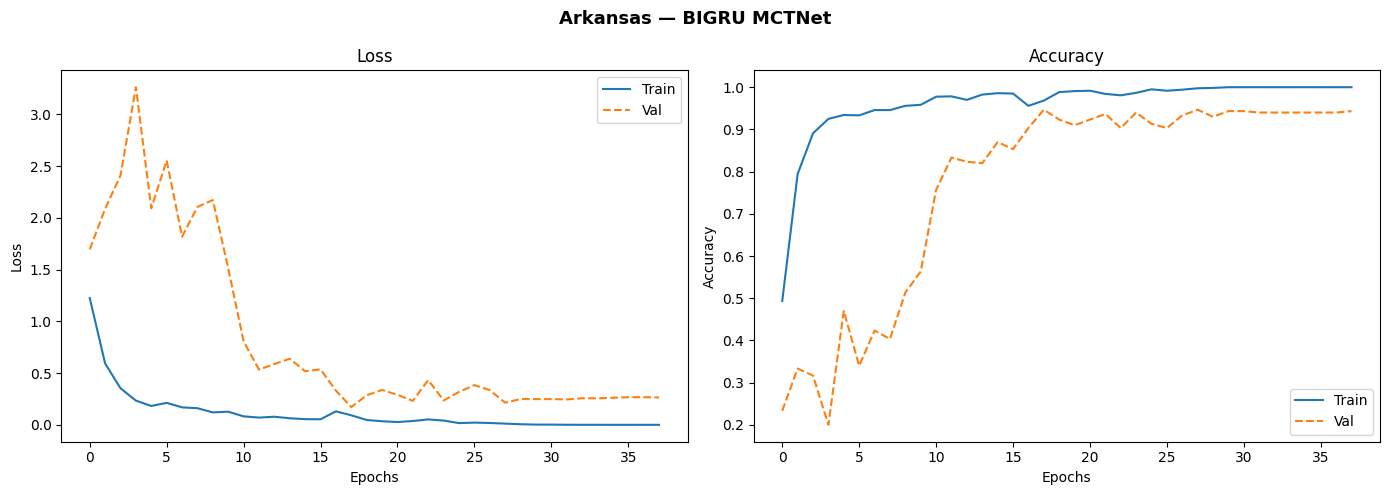

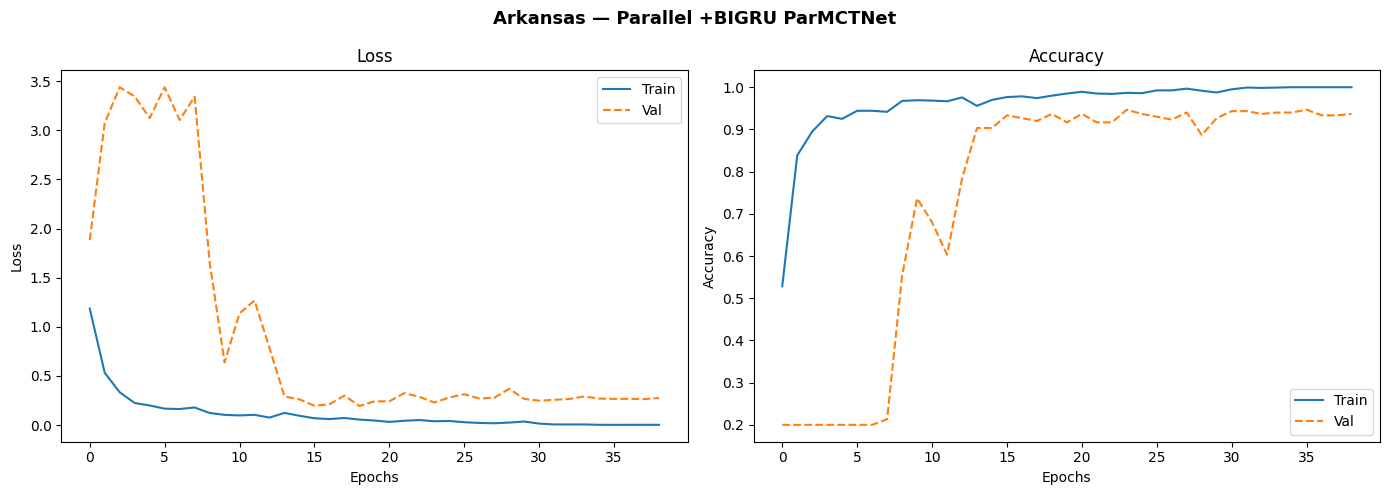

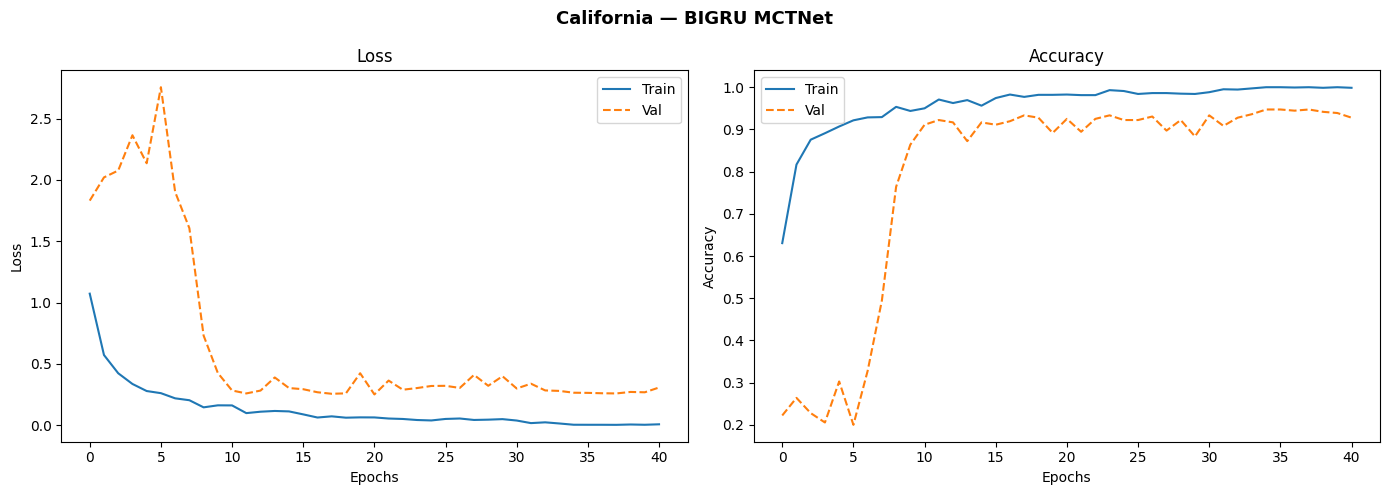

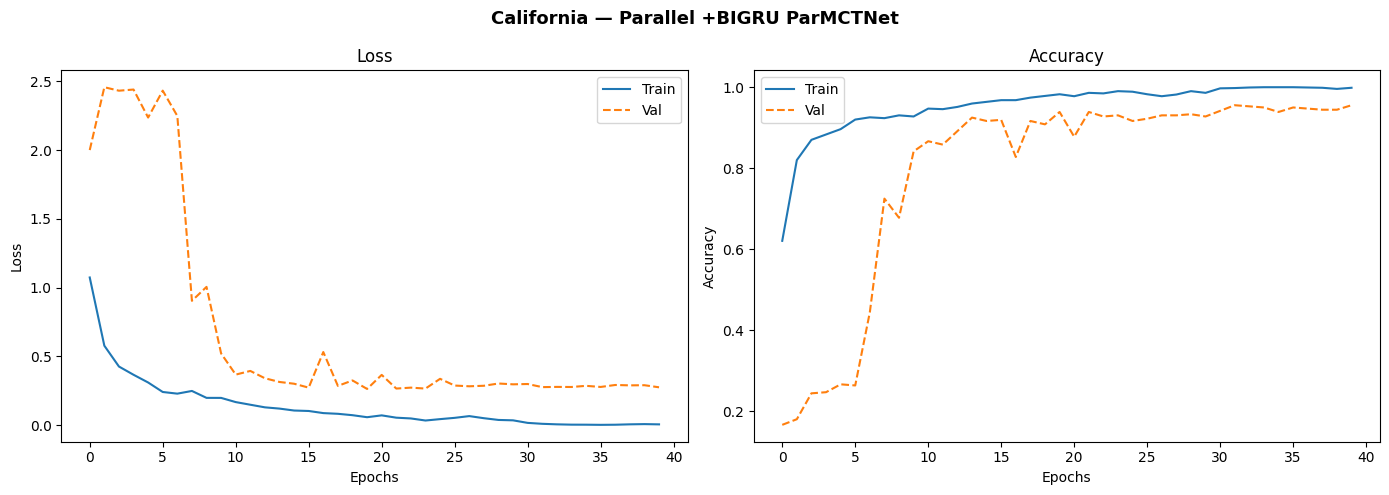

In [11]:
datasets = [
    (history_ar,  history_par_ar,  'Arkansas'),
    (history_ca,  history_par_ca,  'California'),
]
for h_seq, h_par, ds in datasets:

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{ds} — BIGRU MCTNet', fontsize=13, fontweight='bold')
    axes[0].plot(h_seq.history['loss'],     label='Train')
    axes[0].plot(h_seq.history['val_loss'], label='Val', linestyle='--')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(h_seq.history['accuracy'],     label='Train')
    axes[1].plot(h_seq.history['val_accuracy'], label='Val', linestyle='--')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{ds} — Parallel +BIGRU ParMCTNet', fontsize=13, fontweight='bold')

    axes[0].plot(h_par.history['loss'],     label='Train')
    axes[0].plot(h_par.history['val_loss'], label='Val', linestyle='--')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(h_par.history['accuracy'],     label='Train')
    axes[1].plot(h_par.history['val_accuracy'], label='Val', linestyle='--')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()